#Step 1: Load datasets and select relevant columns

In [15]:
import pandas as pd

# Load datasets
mustard_df = pd.read_csv("/content/mustard_clean.csv")
jigsaw_df = pd.read_csv("/content/toxicity_clean.csv")

# Mustard: use SPEAKER as USER
mustard_df = mustard_df[["SPEAKER", "Sarcasm", "Implicit_Emotion", "Explicit_Emotion", "Valence", "Arousal"]]
mustard_df = mustard_df.rename(columns={"SPEAKER":"USER"})

# Jigsaw: use 'target' as USER
jigsaw_df = jigsaw_df[["target", "severe_toxicity", "obscene", "insult", "identity_attack", "threat"]]
jigsaw_df = jigsaw_df.rename(columns={"target":"USER"})

# Convert USER to string to avoid merge issues
mustard_df["USER"] = mustard_df["USER"].astype(str)
jigsaw_df["USER"] = jigsaw_df["USER"].astype(str)

# Check unique users
print("Mustard unique users:", mustard_df["USER"].nunique())
print("Jigsaw unique users:", jigsaw_df["USER"].nunique())


Mustard unique users: 27
Jigsaw unique users: 1422


In [17]:
from sklearn.preprocessing import LabelEncoder

# Columns to encode
emotion_cols = ["Implicit_Emotion", "Explicit_Emotion"]

# Encode each column
for col in emotion_cols:
    le = LabelEncoder()
    mustard_df[col] = le.fit_transform(mustard_df[col].astype(str))

# Now combine datasets
mustard_features = ["USER", "Sarcasm", "Implicit_Emotion", "Explicit_Emotion", "Valence", "Arousal"]
jigsaw_features = ["USER", "severe_toxicity", "obscene", "insult", "identity_attack", "threat"]

mustard_df = mustard_df[mustard_features]
jigsaw_df = jigsaw_df[jigsaw_features]

combined_df = pd.concat([mustard_df, jigsaw_df], axis=0, ignore_index=True)

# Fill missing values with 0
for col in ["Sarcasm", "Implicit_Emotion", "Explicit_Emotion", "Valence", "Arousal",
            "severe_toxicity", "obscene", "insult", "identity_attack", "threat"]:
    if col not in combined_df.columns:
        combined_df[col] = 0
combined_df.fillna(0, inplace=True)

# Aggregate per user
user_emb_df = combined_df.groupby("USER").mean().reset_index()

# Behavioral embeddings (numpy array)
beh_emb = user_emb_df.drop(columns="USER").to_numpy(dtype=np.float32)
all_users = user_emb_df["USER"].tolist()

print("Behavioral embeddings shape:", beh_emb.shape)
print("Number of unique users:", len(all_users))


Behavioral embeddings shape: (1449, 10)
Number of unique users: 1449


In [18]:
import numpy as np

# beh_emb: torch.Tensor of shape [num_users, embedding_dim]
# Convert to NumPy if needed
beh_emb_np = beh_emb.cpu().numpy() if isinstance(beh_emb, torch.Tensor) else beh_emb

# Save to .npy file
np.save("/content/user_beh_emb.npy", beh_emb_np)

# Also save the corresponding user IDs
np.save("/content/user_ids.npy", all_users)

print("Behavioral embeddings and user IDs saved successfully!")


Behavioral embeddings and user IDs saved successfully!


In [19]:
import numpy as np
import torch

# Load behavioral embeddings and user IDs
beh_emb = np.load("/content/user_beh_emb.npy")  # shape: [num_users, embedding_dim]
user_ids = np.load("/content/user_ids.npy")    # shape: [num_users]

# Convert embeddings to torch tensor
x = torch.tensor(beh_emb, dtype=torch.float)

# Number of users / nodes
num_users = x.shape[0]
embedding_dim = x.shape[1]

print("Behavioral embeddings shape:", x.shape)
print("Number of unique users:", num_users)


Behavioral embeddings shape: torch.Size([1449, 10])
Number of unique users: 1449


#Build the user graph using FAISS:

In [21]:
!pip install faiss-cpu -q
import faiss
import torch
import numpy as np

# Load embeddings (assuming you already have them in x)
# Ensure float32 and C-contiguous
embeddings = np.ascontiguousarray(x.numpy().astype('float32'))
num_nodes, embedding_dim = embeddings.shape

# Normalize embeddings for cosine similarity
faiss.normalize_L2(embeddings)

# Create FAISS index
index = faiss.IndexFlatIP(embedding_dim)  # IP ≈ cosine similarity
index.add(embeddings)

# Find top-k neighbors for each node
k = 5  # number of neighbors
distances, neighbors = index.search(embeddings, k+1)  # +1 to include self

# Build undirected edge list
edges = []
for i in range(num_nodes):
    for j in neighbors[i][1:]:  # skip self
        edges.append((i, j))
        edges.append((j, i))  # make undirected

# Convert to torch tensor for PyG
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
print("Edge index shape:", edge_index.shape)


Edge index shape: torch.Size([2, 14490])


In [23]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.6 MB/s eta 0:00:00


In [24]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class GATEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=2):
        super(GATEncoder, self).__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.gat2(x, edge_index)
        return x

In [25]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

x = torch.tensor(embeddings, dtype=torch.float32).to(device)  # behavioral embeddings
edge_index = edge_index.to(device)  # your FAISS graph edges


In [26]:
in_channels = x.shape[1]      # input feature size
hidden_channels = 64           # hidden dimension
out_channels = 16              # final embedding size per user

encoder = GATEncoder(in_channels, hidden_channels, out_channels).to(device)

optimizer = torch.optim.Adam(encoder.parameters(), lr=0.005)
epochs = 50


In [27]:
def edge_loss(z, edge_index):
    # Positive edges
    src, dst = edge_index
    pos_score = torch.sum(z[src] * z[dst], dim=1)
    pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-15).mean()

    # Negative edges (sample random non-edges)
    num_nodes = z.size(0)
    neg_src = torch.randint(0, num_nodes, (edge_index.size(1),), device=device)
    neg_dst = torch.randint(0, num_nodes, (edge_index.size(1),), device=device)
    neg_score = torch.sum(z[neg_src] * z[neg_dst], dim=1)
    neg_loss = -torch.log(1 - torch.sigmoid(neg_score) + 1e-15).mean()

    return pos_loss + neg_loss


In [28]:
for epoch in range(epochs):
    encoder.train()
    optimizer.zero_grad()
    z = encoder(x, edge_index)          # forward pass
    loss = edge_loss(z, edge_index)     # compute loss
    loss.backward()                      # backprop
    optimizer.step()                     # update weights

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 1.3509
Epoch 5, Loss: 1.1934
Epoch 10, Loss: 1.1435
Epoch 15, Loss: 1.1057
Epoch 20, Loss: 1.1097
Epoch 25, Loss: 1.1227
Epoch 30, Loss: 1.1015
Epoch 35, Loss: 1.1051
Epoch 40, Loss: 1.1058
Epoch 45, Loss: 1.1034


In [29]:
z_cpu = z.detach().cpu().numpy()
print("GAT embeddings shape:", z_cpu.shape)


GAT embeddings shape: (1449, 16)


In [30]:
from sklearn.cluster import KMeans

n_clusters = 2  # Trusted vs Untrusted
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(z_cpu)

print("Cluster counts:", np.bincount(cluster_labels))


Cluster counts: [1246  203]


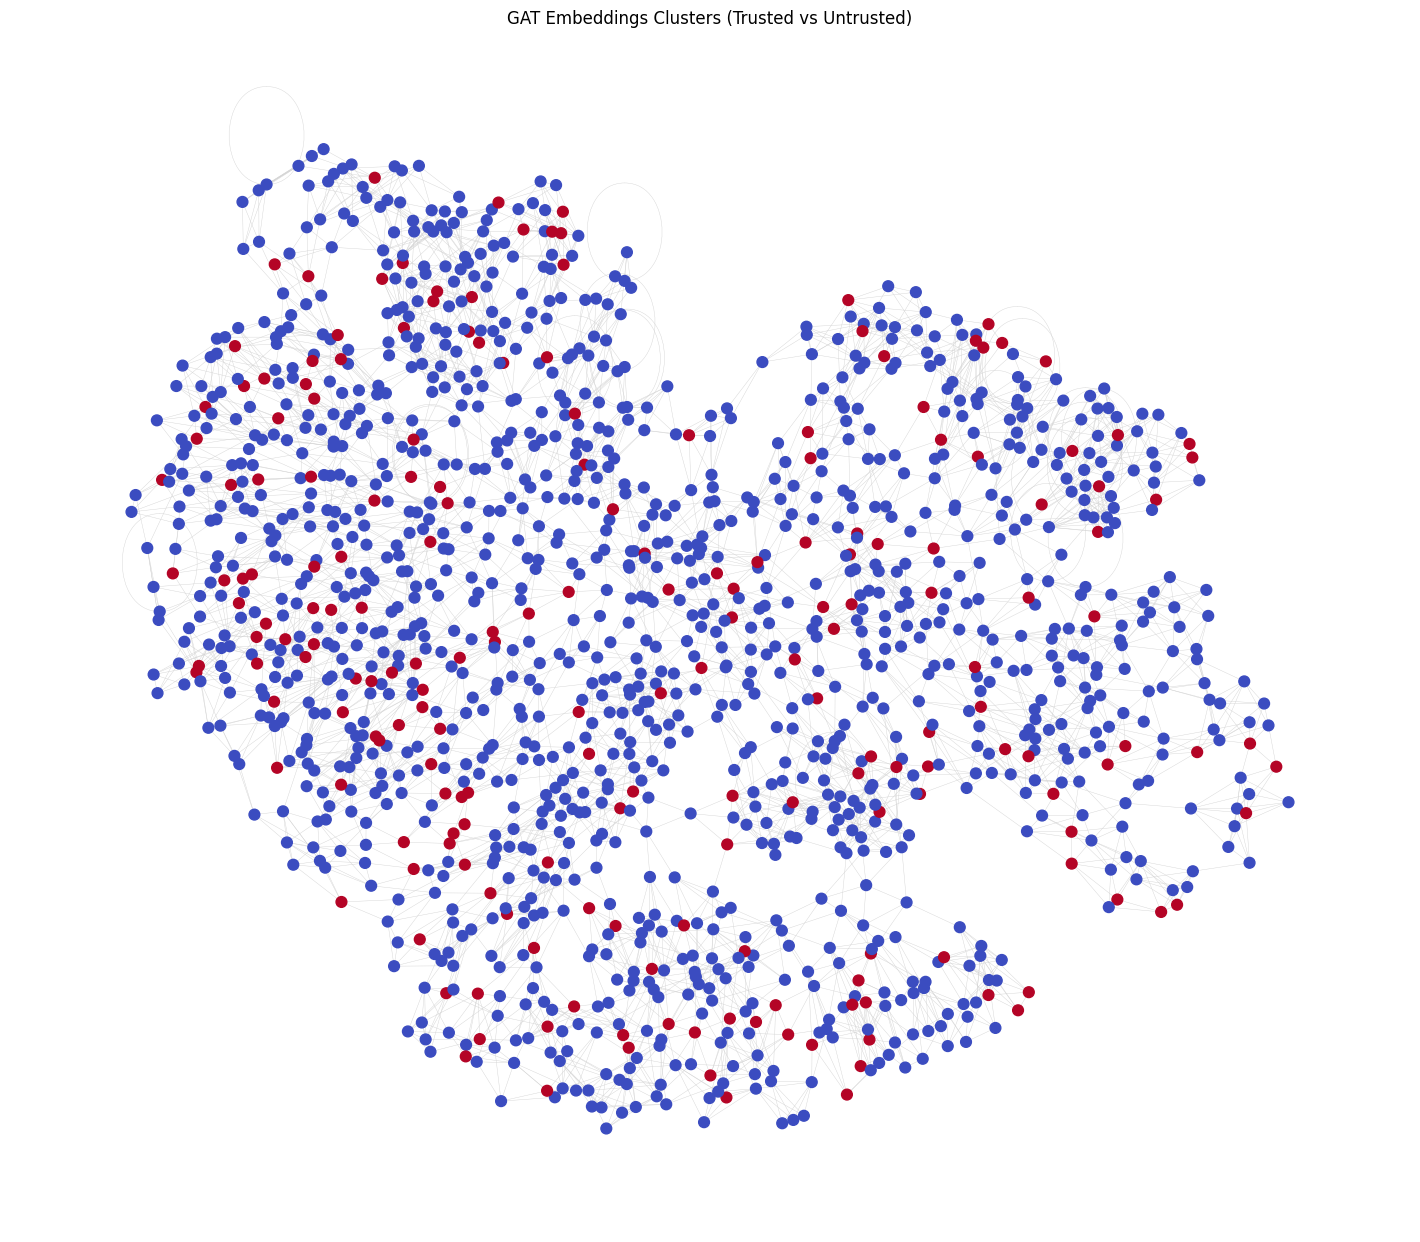

In [31]:
import networkx as nx
import matplotlib.pyplot as plt

# Build graph
edges_list = edge_index.cpu().t().numpy()
G = nx.Graph()
G.add_edges_from(edges_list)

# Node positions
pos = nx.kamada_kawai_layout(G)

# Node colors
colors = cluster_labels

plt.figure(figsize=(14,12))
nx.draw(
    G, pos,
    node_size=60,
    node_color=colors,
    cmap='coolwarm',
    edge_color='lightgray',
    width=0.3,
    with_labels=False
)
plt.title("GAT Embeddings Clusters (Trusted vs Untrusted)")
plt.axis('off')
plt.show()


In [32]:
import pandas as pd

# Suppose cluster_labels is the array from KMeans (0 or 1)
user_df = pd.DataFrame({
    "user": all_users,  # your list of user IDs
    "cluster": cluster_labels
})

# Count users per cluster
print(user_df['cluster'].value_counts())

# Optionally, see users in cluster 0
print(user_df[user_df['cluster'] == 0]['user'].tolist())

# Similarly for cluster 1
print(user_df[user_df['cluster'] == 1]['user'].tolist())


cluster
0    1246
1     203
Name: count, dtype: int64
['0.000733137829912', '0.0009157509157509', '0.0017528483786152', '0.0017761989342806', '0.0028901734104046', '0.0029006526468455', '0.0030921459492888', '0.0036764705882352', '0.0049261083743842', '0.0051508462104488', '0.0072910824453168', '0.0074404761904761', '0.0094258783204798', '0.0102905569007263', '0.0107372942018611', '0.0161290322580645', '0.025260029717682', '0.0294117647058823', '0.03125', '0.0333333333333333', '0.0338278931750741', '0.0434782608695652', '0.0491803278688524', '0.05', '0.0526315789473684', '0.054054054054054', '0.0555555555555555', '0.0571428571428571', '0.0588235294117647', '0.064', '0.064516129032258', '0.0697674418604651', '0.0714285714285714', '0.075', '0.0789473684210526', '0.0909090909090909', '0.0930232558139534', '0.1', '0.1020408163265306', '0.1052631578947368', '0.1081081081081081', '0.108695652173913', '0.1111111111111111', '0.1136363636363636', '0.1153846153846154', '0.1162790697674418', '0.1

In [33]:
import pandas as pd

# Create DataFrame
user_cluster_df = pd.DataFrame({
    'user_id': user_ids,        # from /content/user_ids.npy
    'cluster': cluster_labels   # from KMeans
})

# Label clusters as Trusted / Untrusted based on counts
trusted_label = 0 if (user_cluster_df['cluster'].value_counts().idxmax() == 0) else 1
user_cluster_df['Trust_Status'] = user_cluster_df['cluster'].apply(lambda x: 'Trusted' if x == trusted_label else 'Untrusted')

# Show summary
print(user_cluster_df['Trust_Status'].value_counts())
display(user_cluster_df.head(10))


Trust_Status
Trusted      1246
Untrusted     203
Name: count, dtype: int64


,user_id,cluster,Trust_Status
0,0.0,1,Untrusted
1,0.0006013229104028,1,Untrusted
2,0.000733137829912,0,Trusted
3,0.0009157509157509,0,Trusted
4,0.0017528483786152,0,Trusted
5,0.0017761989342806,0,Trusted
6,0.0028901734104046,0,Trusted
7,0.0029006526468455,0,Trusted
8,0.0030921459492888,0,Trusted
9,0.0036764705882352,0,Trusted


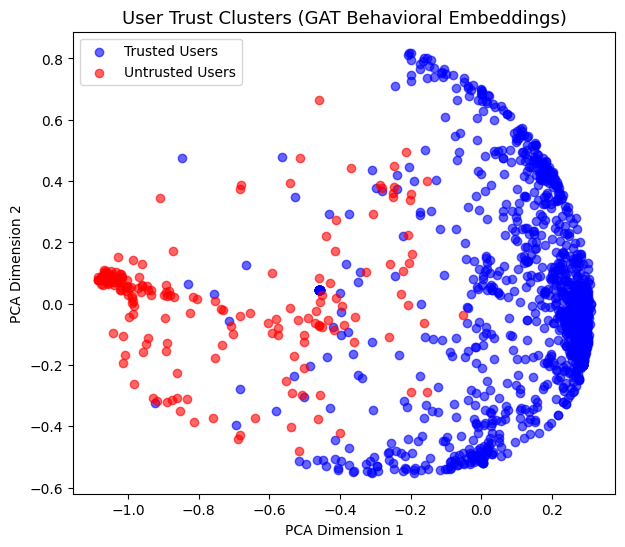

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# Plot Trusted vs Untrusted
plt.figure(figsize=(7, 6))
plt.scatter(reduced[user_cluster_df['Trust_Status'] == 'Trusted', 0],
            reduced[user_cluster_df['Trust_Status'] == 'Trusted', 1],
            c='blue', label='Trusted Users', alpha=0.6)

plt.scatter(reduced[user_cluster_df['Trust_Status'] == 'Untrusted', 0],
            reduced[user_cluster_df['Trust_Status'] == 'Untrusted', 1],
            c='red', label='Untrusted Users', alpha=0.6)

plt.title("User Trust Clusters (GAT Behavioral Embeddings)", fontsize=13)
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend()
plt.show()


In [35]:
user_cluster_df.to_csv("/content/user_trust_clusters.csv", index=False)
print(" Saved: /content/user_trust_clusters.csv")


 Saved: /content/user_trust_clusters.csv


In [39]:
import pandas as pd

# Load datasets
mustard_df = pd.read_csv("/content/mustard_clean.csv")
jigsaw_df = pd.read_csv("/content/toxicity_clean.csv")

# Mustard: use SPEAKER as USER
mustard_df["USER"] = mustard_df["SPEAKER"]

# Jigsaw: use id as USER (or publication_id if it represents users)
jigsaw_df["USER"] = jigsaw_df["id"]  # if "id" = comment/user id
# If "publication_id" or "article_id" represents the user, replace accordingly

# Select relevant features
mustard_features = ["USER", "Sarcasm", "Implicit_Emotion", "Explicit_Emotion", "Valence", "Arousal"]
jigsaw_features = ["USER", "target", "severe_toxicity", "obscene", "insult", "identity_attack", "threat"]

mustard_df = mustard_df[mustard_features]
jigsaw_df = jigsaw_df[jigsaw_features]

# Combine them
merged_df = pd.concat([mustard_df, jigsaw_df], ignore_index=True)
print("Merged data shape:", merged_df.shape)
print("Merged unique users:", merged_df["USER"].nunique())
import numpy as np

beh_emb = np.load("/content/user_beh_emb.npy")
user_ids = np.load("/content/user_ids.npy", allow_pickle=True)

print("Behavioral embedding shape:", beh_emb.shape)
print("User IDs shape:", user_ids.shape)
import pandas as pd

user_emb_df = pd.DataFrame({
    "USER": user_ids,
})
print(user_emb_df.head())


Merged data shape: (92104, 12)
Merged unique users: 90929
Behavioral embedding shape: (1449, 10)
User IDs shape: (1449,)
                 USER
0                 0.0
1  0.0006013229104028
2   0.000733137829912
3  0.0009157509157509
4  0.0017528483786152


#Cell 1 — Load data

In [51]:
import numpy as np
import pandas as pd

# Load behavioral embeddings and user IDs
embeddings = np.load('/content/user_beh_emb.npy')  # shape: (num_users, feature_dim)
user_ids = np.load('/content/user_ids.npy')       # shape: (num_users,)

print("Embeddings shape:", embeddings.shape)
print("User IDs shape:", user_ids.shape)


Embeddings shape: (1449, 10)
User IDs shape: (1449,)


#Cell 2 — Normalize embeddings

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
embeddings_norm = scaler.fit_transform(embeddings)

print("First 5 normalized embeddings:\n", embeddings_norm[:5])


First 5 normalized embeddings:
 [[-0.11760248 -0.13277112 -0.13569324 -0.13644728 -0.13746701 -0.9756526
  -0.8889507  -1.8804585  -0.6177142  -0.50490224]
 [-0.11760248 -0.13277112 -0.13569324 -0.13644728 -0.13746701 -0.9756526
  -0.8901882  -1.8837291  -0.6215179  -0.50452733]
 [-0.11760248 -0.13277112 -0.13569324 -0.13644728 -0.13746701 -0.9756526
  -0.8901882  -1.8837291  -0.6189337  -0.50659406]
 [-0.11760248 -0.13277112 -0.13569324 -0.13644728 -0.13746701 -0.9756526
  -0.8901882  -1.8823007  -0.6199039  -0.50659406]
 [-0.11760248 -0.13277112 -0.13569324 -0.13644728 -0.13746701 -0.9756526
  -0.8901882  -1.8809949  -0.6215179  -0.50659406]]


#Cell 3 — Define simple contrastive learning model

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'

class ContrastiveModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, projection_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.projection_head = nn.Sequential(
            nn.Linear(hidden_dim, projection_dim),
            nn.ReLU(),
            nn.Linear(projection_dim, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        z = F.normalize(z, dim=1)  # normalize for contrastive loss
        return z


#Cell 4 — Prepare PyTorch dataset

In [54]:
from torch.utils.data import Dataset, DataLoader

class EmbeddingDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = torch.tensor(embeddings, dtype=torch.float32)

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        x = self.embeddings[idx]
        return x, x  # For simplicity, use same embedding as positive pair

dataset = EmbeddingDataset(embeddings_norm)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)


#Cell 5 — Define contrastive loss (NT-Xent)

In [55]:
def nt_xent_loss(z_i, z_j, temperature=0.5):
    z = torch.cat([z_i, z_j], dim=0)
    sim_matrix = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)

    N = z_i.size(0)
    mask = (~torch.eye(2*N, 2*N, dtype=bool)).to(device)

    exp_sim = torch.exp(sim_matrix / temperature) * mask
    pos_sim = torch.exp(F.cosine_similarity(z_i, z_j, dim=1) / temperature)

    loss = -torch.log(pos_sim / exp_sim.sum(dim=1)[:N])
    return loss.mean()


#Cell 6 — Train the contrastive model

In [56]:
input_dim = embeddings_norm.shape[1]
model = ContrastiveModel(input_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x_i, x_j in dataloader:
        x_i = x_i.to(device)
        x_j = x_j.to(device)

        z_i = model(x_i)
        z_j = model(x_j)

        loss = nt_xent_loss(z_i, z_j)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.4f}")


Epoch 1/20, Loss: 3.9675
Epoch 2/20, Loss: 3.4631
Epoch 3/20, Loss: 3.3325
Epoch 4/20, Loss: 3.2974
Epoch 5/20, Loss: 3.2576
Epoch 6/20, Loss: 3.2283
Epoch 7/20, Loss: 3.2033
Epoch 8/20, Loss: 3.1799
Epoch 9/20, Loss: 3.1746
Epoch 10/20, Loss: 3.1487
Epoch 11/20, Loss: 3.1403
Epoch 12/20, Loss: 3.1246
Epoch 13/20, Loss: 3.1245
Epoch 14/20, Loss: 3.1049
Epoch 15/20, Loss: 3.0962
Epoch 16/20, Loss: 3.0901
Epoch 17/20, Loss: 3.0819
Epoch 18/20, Loss: 3.0632
Epoch 19/20, Loss: 3.0656
Epoch 20/20, Loss: 3.0736


#Cell 7 — Get embeddings from trained model

In [57]:
model.eval()
with torch.no_grad():
    embeddings_cl = model(torch.tensor(embeddings_norm, dtype=torch.float32).to(device))
    embeddings_cl = embeddings_cl.cpu().numpy()

print("Contrastive embeddings shape:", embeddings_cl.shape)


Contrastive embeddings shape: (1449, 32)


#Cell 8 — Cluster embeddings using k-means

In [58]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
cl_clusters = kmeans.fit_predict(embeddings_cl)

print("Cluster counts:", np.bincount(cl_clusters))


Cluster counts: [659 790]


#Cell 9 — Map clusters to Trusted/Untrusted

In [ ]:

trusted_cluster = np.argmin(np.bincount(cl_clusters))
untrusted_cluster = 1 - trusted_cluster

cluster_labels = np.array(['Trusted' if c == trusted_cluster else 'Untrusted' for c in cl_clusters])

df_result = pd.DataFrame({
    'user_id': user_ids,
    'contrastive_cluster': cl_clusters,
    'trust_status': cluster_labels
})

df_result.head()


,user_id,contrastive_cluster,trust_status
0,0.0,0,Trusted
1,0.0006013229104028,0,Trusted
2,0.000733137829912,0,Trusted
3,0.0009157509157509,0,Trusted
4,0.0017528483786152,0,Trusted


#Cell 10 — Visualize clusters using PCA

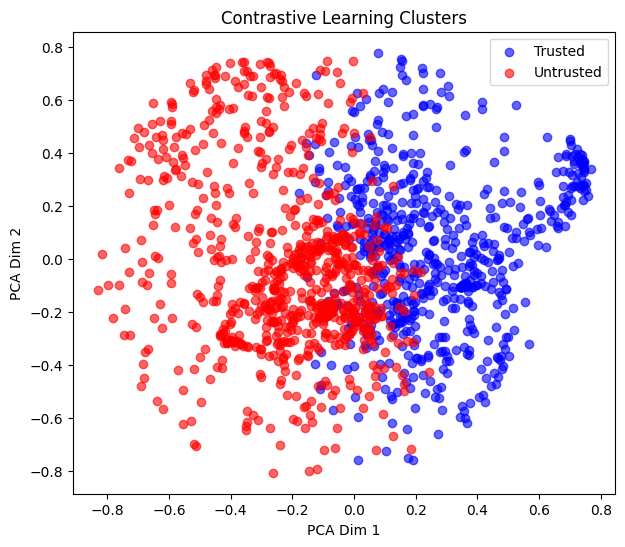

In [60]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings_cl)

plt.figure(figsize=(7,6))
plt.scatter(reduced[cluster_labels=='Trusted', 0],
            reduced[cluster_labels=='Trusted', 1],
            c='blue', label='Trusted', alpha=0.6)
plt.scatter(reduced[cluster_labels=='Untrusted', 0],
            reduced[cluster_labels=='Untrusted', 1],
            c='red', label='Untrusted', alpha=0.6)
plt.title("Contrastive Learning Clusters")
plt.xlabel("PCA Dim 1")
plt.ylabel("PCA Dim 2")
plt.legend()
plt.show()


#Load both cluster CSV files

In [63]:
import pandas as pd

gat_df = pd.read_csv('/content/user_trust_clusters.csv')
cl_df = pd.read_csv('/content/contrastive_trust_labels.csv')

print("GAT CSV columns:", gat_df.columns)
print("Contrastive CSV columns:", cl_df.columns)


GAT CSV columns: Index(['user_id', 'cluster', 'Trust_Status'], dtype='object')
Contrastive CSV columns: Index(['User_ID', 'Trust_Status'], dtype='object')


In [65]:
import pandas as pd

# Load GAT clusters
gat_df = pd.read_csv('/content/user_trust_clusters.csv')  # columns: user_id, cluster, Trust_Status

# Load Contrastive Learning clusters
cl_df = pd.read_csv('/content/contrastive_trust_labels.csv')  # columns: User_ID, Trust_Status

# Rename Contrastive CSV column to match GAT
cl_df = cl_df.rename(columns={'User_ID': 'user_id', 'Trust_Status': 'Trust_Status_cl'})
gat_df = gat_df.rename(columns={'Trust_Status': 'Trust_Status_gat', 'cluster': 'cluster_gat'})


In [66]:
# Merge on user_id
merged_df = gat_df.merge(cl_df, on='user_id')
merged_df.head()


,user_id,cluster_gat,Trust_Status_gat,Trust_Status_cl
0,0.0,1,Untrusted,Trusted
1,0.0006013229104028,1,Untrusted,Untrusted
2,0.000733137829912,0,Trusted,Trusted
3,0.0009157509157509,0,Trusted,Trusted
4,0.0017528483786152,0,Trusted,Trusted


In [67]:
# Count clusters in GAT
print("GAT Cluster Counts:")
print(merged_df['cluster_gat'].value_counts())

# Count clusters in Contrastive Learning
print("\nContrastive Learning Cluster Counts:")
print(merged_df['Trust_Status_cl'].value_counts())


GAT Cluster Counts:
cluster_gat
0    1246
1     203
Name: count, dtype: int64

Contrastive Learning Cluster Counts:
Trust_Status_cl
Trusted      977
Untrusted    472
Name: count, dtype: int64


In [68]:
# Find where GAT and Contrastive disagree
merged_df['disagreement'] = merged_df['cluster_gat'].astype(str) + "_" + merged_df['Trust_Status_cl'].astype(str)

# Count the types of disagreements
print("\nDisagreement counts between GAT and Contrastive Learning:")
print(merged_df['disagreement'].value_counts())



Disagreement counts between GAT and Contrastive Learning:
disagreement
0_Trusted      937
0_Untrusted    309
1_Untrusted    163
1_Trusted       40
Name: count, dtype: int64


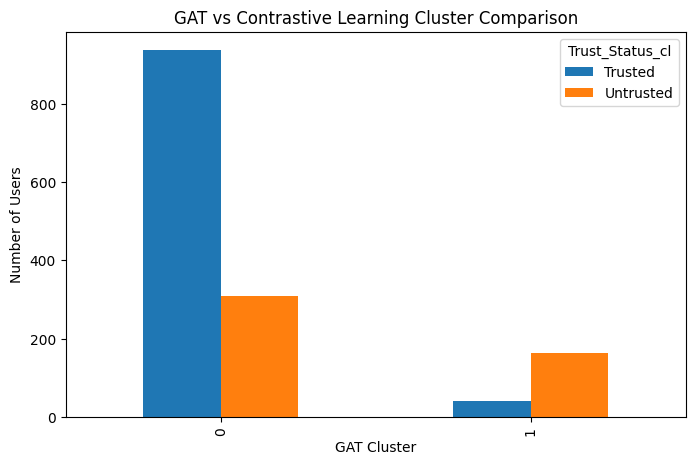

In [69]:
import matplotlib.pyplot as plt

# Basic bar plot for GAT vs Contrastive
counts = pd.crosstab(merged_df['cluster_gat'], merged_df['Trust_Status_cl'])
counts.plot(kind='bar', figsize=(8,5))
plt.title("GAT vs Contrastive Learning Cluster Comparison")
plt.xlabel("GAT Cluster")
plt.ylabel("Number of Users")
plt.show()


In [70]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix


In [72]:
# Load GAT clusters
gat_df = pd.read_csv('/content/user_trust_clusters.csv')

# Load Contrastive Learning clusters
cl_df = pd.read_csv('/content/contrastive_trust_labels.csv')

# Make sure column names match for merging later
cl_df.rename(columns={'User_ID': 'user_id'}, inplace=True)

# Quick check
print("GAT CSV columns:", gat_df.columns)
print("Contrastive CSV columns:", cl_df.columns)


GAT CSV columns: Index(['user_id', 'cluster', 'Trust_Status'], dtype='object')
Contrastive CSV columns: Index(['user_id', 'Trust_Status'], dtype='object')
